# Thyroid Disease Detection: Anomaly Detection with Gaussian Mixture Models

**Dataset:** Thyroid Disease — 3,772 patient records, 6 clinical features, binary label (hypothyroid yes/no).

**Problem:** Extreme class imbalance (97.5% / 2.5%) makes this an anomaly-detection task. Standard classifiers biased toward the majority class fail here — the goal is to reliably surface the rare positive cases.

**Approach:** Progressive GMM-based anomaly detection: univariate → bivariate → class-conditional → full multivariate mixture, with threshold tuning to maximise F1 on a held-out validation set.

---

## 1. Data

**Dataset:** Thyroid Disease dataset — 3,772 patient records with 6 anonymised clinical attributes (Attribute0–5, pre-normalised to [0, 1]).

**Target:** `hypothyroid` (binary) — 0 = healthy, 1 = hypothyroid.

**Class imbalance:** 97.5% negative / 2.5% positive, making this a classic anomaly-detection problem where the minority class is the signal.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_csv("data/Thyroid_Disease.csv", index_col=0)
print(f"Shape: {df.shape}")
df.head()

In [ ]:
# Number of rows in the dataset
num_rows = df.shape[0]
print("Number of rows in the dataset:", num_rows)

Number of rows in the dataset: 3772


In [ ]:
# Unique values in the hypothyroid column
unique_hypothyroid_values = df['hypothyroid'].unique()
print("Unique values in the 'hypothyroid' column:", unique_hypothyroid_values)

Unique values in the 'hypothyroid' column: [0. 1.]


### 1.1 Class Distribution

In [ ]:
# Calculating the percentage of entries for each class in the 'hypothyroid' column
hypothyroid_counts = df['hypothyroid'].value_counts(normalize=True) * 100
print("Percentage of entries for each class in the 'hypothyroid' column:\n", hypothyroid_counts)

Percentage of entries for each class in the 'hypothyroid' column:
 hypothyroid
0.0    97.534464
1.0     2.465536
Name: proportion, dtype: float64


The dataset is **heavily imbalanced**: ~97.5% of records are class 0 (healthy) and only ~2.5% are class 1 (hypothyroid). Standard accuracy would be misleading here — a model that always predicts 'healthy' would achieve 97.5% accuracy while detecting zero cases. **F1 score and AUC** are the appropriate metrics.

### 1.2 Train / Validation / Test Split

Stratified 70 / 15 / 15 split, `random_state=0`.

In [ ]:
### Split the data  ###



from sklearn.model_selection import train_test_split

# Step 1: Separate features (X) and target (y)
X = df.drop(columns=['hypothyroid'])  # Features (Attributes)
y = df['hypothyroid']  # Target (hypothyroid column)

# Step 2: Split the data into training (70%) and temporary (30%) sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=0)

# Step 3: Split the temporary set into validation (15%) and testing (15%) sets
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=0)

# Output the sizes of the splits for verification
print(f"Training set size: {X_train.shape[0]} rows")
print(f"Validation set size: {X_val.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")

### 1.3 Feature Distributions by Class

Attribute0
Attribute1
Attribute2
Attribute3
Attribute4
Attribute5


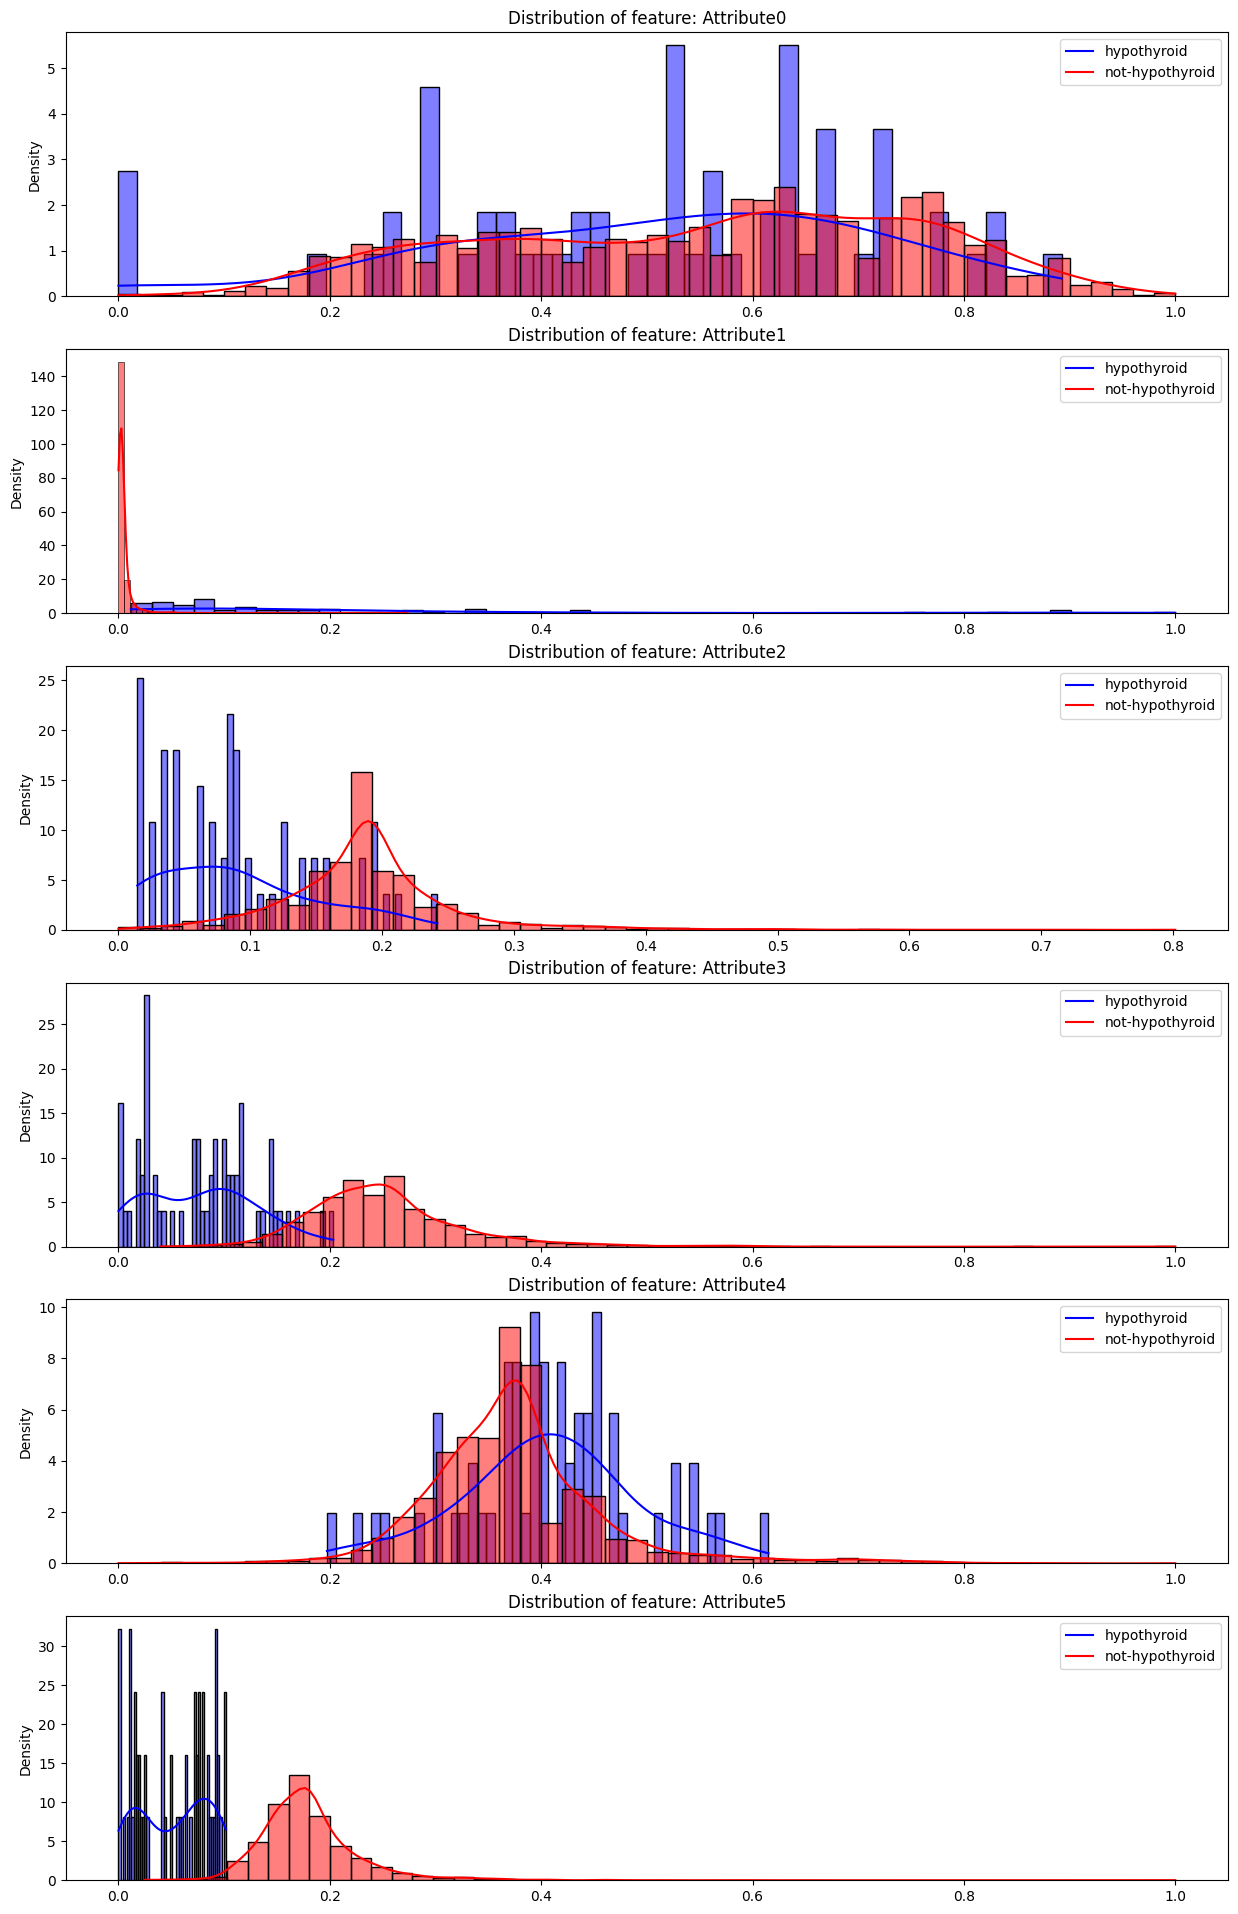

In [ ]:
import matplotlib.gridspec as gridspec
features=list(df.columns[:-1])
nplots=np.size(features)
plt.figure(figsize=(15,4*nplots))
gs = gridspec.GridSpec(nplots,1)
for i, feat in enumerate(features):
    print(feat)
    ax = plt.subplot(gs[i])
    sns.histplot(X_train[feat][y_train==1], stat="density", kde=True, color="blue", bins=50)
    sns.histplot(X_train[feat][y_train==0], stat="density", kde=True, color="red", bins=50)
    ax.legend(['hypothyroid', 'not-hypothyroid'],loc='best')
    ax.set_xlabel('')
    ax.set_title('Distribution of feature: ' + feat)

The histograms above show per-feature density for healthy (blue) vs hypothyroid (orange) patients. Features like Attribute3 and Attribute5 show roughly bell-shaped distributions for the majority class — a good sign that Gaussian models will fit well. Attribute2 is right-skewed and may benefit from a multi-component mixture.

The graphs highlight differences in feature distributions between hypothyroid and not-hypothyroid classes, crucial for anomaly detection with a Gaussian model:

Gaussian Fit: Features like Attribute3 and Attribute5, with bell-shaped distributions for the not-hypothyroid class, fit well with a Gaussian model. The hypothyroid class deviates, making these features useful for anomaly detection.


Skewed Features: Attribute2 is skewed and may require transformation to meet the Gaussian assumption.


Class Overlap: Attribute0 and Attribute1 show significant overlap between classes, reducing their effectiveness for anomaly detection.


In summary, the Gaussian model is best suited for features with distinct class separation, while skewed features may need transformation.

## 2. Univariate Gaussian Models

Fit a single Gaussian (`GaussianMixture(n_components=1)`) to each feature independently. Use the log-likelihood score as an anomaly score and evaluate with ROC AUC. Identify the top 3 features and tune a decision threshold to maximise F1 on the validation set.

### 2.1 Per-Feature AUC

In [ ]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

# Features to evaluate
features = list(df.columns[:-1])  # Assuming the last column is the target 'hypothyroid'

# Step 1: Fit a single Gaussian distribution for each feature and compute AUC
train_aucs = []
val_aucs = []
for feat in features:
    # Fit GaussianMixture on the full training data (both classes)
    gm = GaussianMixture(n_components=1, random_state=0)
    gm.fit(X_train[[feat]])

    # Compute log likelihood scores for training and validation sets
    train_scores = gm.score_samples(X_train[[feat]])
    val_scores = gm.score_samples(X_val[[feat]])

    # Calculate AUC on the training set and validation set
    train_auc = roc_auc_score(y_train, train_scores)
    val_auc = roc_auc_score(y_val, val_scores)

    train_aucs.append(train_auc)
    val_aucs.append(val_auc)

# Create a dataframe with the results
results_df = pd.DataFrame({
    'Feature': features,
    'Training AUC': train_aucs,
    'Validation AUC': val_aucs
})

# Display the AUC results for all features
print("AUC for all features (training and validation):")
print(results_df)


AUC for all features (training and validation):
      Feature  Training AUC  Validation AUC
0  Attribute0      0.543923        0.477132
1  Attribute1      0.049349        0.004477
2  Attribute2      0.194315        0.170296
3  Attribute3      0.059672        0.050877
4  Attribute4      0.422708        0.405082
5  Attribute5      0.032825        0.034362


### 2.2 Top 3 Features by Validation AUC

In [ ]:
# Sort features by validation AUC and select the top 3
top_3_features = results_df.sort_values('Validation AUC', ascending=False).head(3)

# Display the top 3 features based on validation AUC
print("Top 3 features based on validation AUC:")
print(top_3_features)

Top 3 features based on validation AUC:
      Feature  Training AUC  Validation AUC
0  Attribute0      0.543923        0.477132
4  Attribute4      0.422708        0.405082
2  Attribute2      0.194315        0.170296


In [ ]:
# Store the score samples for the top 3 features
for feat in top_3_features['Feature']:
    gm = GaussianMixture(n_components=1, random_state=0)
    gm.fit(X_train[[feat]])

    # Get validation scores (log likelihood) for each feature
    val_scores = gm.score_samples(X_val[[feat]])

    # Display score samples for the validation set for each top feature
    print(f"Score samples for feature: {feat}")
    print(val_scores[:10])  # Showing only the first 10 scores for brevity

Score samples for feature: Attribute0
[ 0.50166885  0.31681235  0.66970068  0.21878747 -0.66155167 -0.12714482
  0.35979749  0.58120535 -1.23566675  0.63675475]
Score samples for feature: Attribute4
[1.51083623 1.0881266  1.51083623 1.51155341 0.77472077 0.86891508
 1.51155341 1.51155341 1.51155341 1.28014969]
Score samples for feature: Attribute2
[1.72660799 1.26626743 1.69573149 1.69573149 1.42925809 1.38883778
 1.72660799 1.73786577 1.73786577 1.66840297]


### 2.3 Threshold Optimisation (F1)

In [ ]:
from sklearn.metrics import f1_score

optimal_thresholds = []
f1_scores = []

# Step 4: Find the optimal threshold for F1 score
for feat in top_3_features['Feature']:
    gm = GaussianMixture(n_components=1, random_state=0)
    gm.fit(X_train[[feat]])

    val_scores = gm.score_samples(X_val[[feat]])

    # Use percentiles of the scores as potential thresholds
    thresholds = np.percentile(val_scores, np.arange(1, 100, 1))  # Percentile-based threshold search
    best_f1 = 0
    best_threshold = None

    for threshold in thresholds:
        # Predict hypothyroid if the score is below the threshold
        val_predictions = (val_scores < threshold).astype(int)

        # Compute the F1 score
        f1 = f1_score(y_val, val_predictions)

        # Track the best F1 score and corresponding threshold
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold

    # Store the best threshold and F1 score for the feature
    optimal_thresholds.append(best_threshold)
    f1_scores.append(best_f1)

# Output the optimal thresholds and F1 scores for each feature
print("Optimal thresholds and F1 scores for top 3 features:")
for feat, threshold, f1 in zip(top_3_features['Feature'], optimal_thresholds, f1_scores):
    print(f"Feature: {feat}, Optimal Threshold: {threshold}, F1 Score: {f1}")


Optimal thresholds and F1 scores for top 3 features:
Feature: Attribute0, Optimal Threshold: 0.4486871637007796, F1 Score: 0.06876790830945559
Feature: Attribute4, Optimal Threshold: 0.9842152078339059, F1 Score: 0.0847457627118644
Feature: Attribute2, Optimal Threshold: 0.37833421186566696, F1 Score: 0.32142857142857145


In [ ]:
# Create and display a final dataframe with optimal thresholds and F1 scores
optimal_df = pd.DataFrame({
    'Feature': top_3_features['Feature'],
    'Optimal Threshold': optimal_thresholds,
    'F1 Score': f1_scores
})

print("Final table with optimal thresholds and F1 scores for top 3 features:")
print(optimal_df)


Final table with optimal thresholds and F1 scores for top 3 features:
      Feature  Optimal Threshold  F1 Score
0  Attribute0           0.448687  0.068768
4  Attribute4           0.984215  0.084746
2  Attribute2           0.378334  0.321429


### 2.4 Computational Complexity

In [ ]:
# Complexity Report:
# Fitting GaussianMixture is O(n), where n is the number of data points.
# Calculating score_samples is also O(n).
# Sorting the scores for percentile-based threshold search is O(n log n).
# Checking each threshold is O(n).
# Total complexity per feature is O(n log n) due to sorting.

print("The complexity for finding the optimal threshold per feature is O(n log n).")


The complexity for finding the optimal threshold per feature is O(n log n).


## 3. Bivariate Gaussian Mixture Models

Extend to pairs of features using `GaussianMixture(n_components=2)`. The component count is chosen visually from the scatter plot.

### 3.1 Feature Pair: Attribute3 × Attribute4

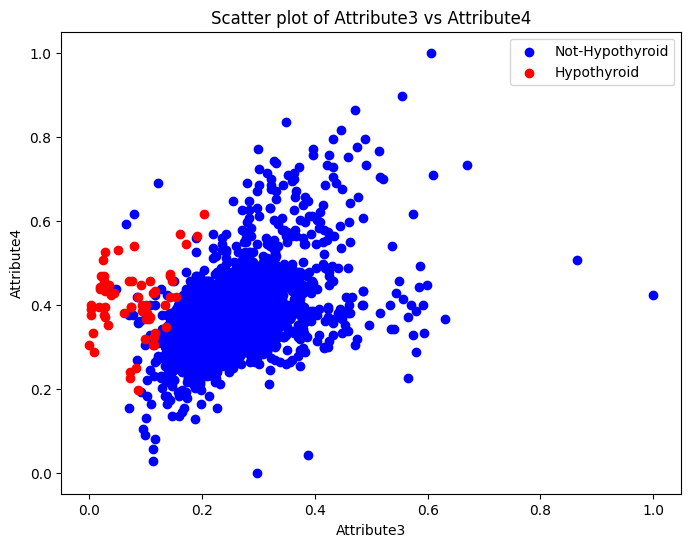

In [ ]:
import matplotlib.pyplot as plt

# Example features
feature_x = 'Attribute3'
feature_y = 'Attribute4'

# Scatter plot of the two features, color by class
plt.figure(figsize=(8,6))
plt.scatter(X_train[feature_x][y_train == 0], X_train[feature_y][y_train == 0], color='blue', label='Not-Hypothyroid')
plt.scatter(X_train[feature_x][y_train == 1], X_train[feature_y][y_train == 1], color='red', label='Hypothyroid')
plt.xlabel(feature_x)
plt.ylabel(feature_y)
plt.legend()
plt.title('Scatter plot of Attribute3 vs Attribute4')
plt.show()


In [ ]:
# Decide n_components based on scatter plot (example, n_components = 2)
n_components = 2

# Fit Gaussian Mixture model on the selected pair of features
gm = GaussianMixture(n_components=n_components, random_state=0)
gm.fit(X_train[[feature_x, feature_y]])

# Output the fitted GaussianMixture model
print(f"Fitted Gaussian Mixture model with {n_components} components for {feature_x} and {feature_y}.")

Fitted Gaussian Mixture model with 2 components for Attribute3 and Attribute4.


### 3.2 AUC for Additional Feature Pairs

In [ ]:
# Compute log-likelihood scores for training and validation sets
train_scores = gm.score_samples(X_train[[feature_x, feature_y]])
val_scores = gm.score_samples(X_val[[feature_x, feature_y]])

# Compute AUC for both training and validation sets
train_auc = roc_auc_score(y_train, train_scores)
val_auc = roc_auc_score(y_val, val_scores)

print(f'AUC (Training Set): {train_auc}')
print(f'AUC (Validation Set): {val_auc}')

AUC (Training Set): 0.05398585040586325
AUC (Validation Set): 0.046218995765275245


Repeat the fit for three additional feature pairs and record AUC scores.

In [ ]:
# Repeat the same process for three new feature pairs
new_feature_pairs = [('Attribute1', 'Attribute2'), ('Attribute5', 'Attribute0'), ('Attribute2', 'Attribute5')]

for feature_x, feature_y in new_feature_pairs:
    # Scatter plot (optional, you can repeat Step 1)

    # Fit the Gaussian Mixture model
    gm = GaussianMixture(n_components=2, random_state=0)
    gm.fit(X_train[[feature_x, feature_y]])

    # Compute log-likelihood scores
    train_scores = gm.score_samples(X_train[[feature_x, feature_y]])
    val_scores = gm.score_samples(X_val[[feature_x, feature_y]])

    # Compute AUC
    train_auc = roc_auc_score(y_train, train_scores)
    val_auc = roc_auc_score(y_val, val_scores)

    print(f'Pair: ({feature_x}, {feature_y}) -> AUC (Training): {train_auc}, AUC (Validation): {val_auc}')


Pair: (Attribute1, Attribute2) -> AUC (Training): 0.02321397923963411, AUC (Validation): 0.019721718088324236
Pair: (Attribute5, Attribute0) -> AUC (Training): 0.04639617592280653, AUC (Validation): 0.04355716878402903
Pair: (Attribute2, Attribute5) -> AUC (Training): 0.05472956222706729, AUC (Validation): 0.0486388384754991


### 3.3 Threshold Optimisation & F1 Scores

In [ ]:
# Include the original feature pair along with new feature pairs
all_feature_pairs = [('Attribute3', 'Attribute4'), ('Attribute5', 'Attribute0'), ('Attribute2', 'Attribute5'), ('Attribute1', 'Attribute2')]

# Initialize list to store best thresholds and F1 scores
optimal_thresholds = []
best_f1_scores = []

# Find optimal threshold for each pair
for feature_x, feature_y in all_feature_pairs:
    # Fit Gaussian Mixture
    gm = GaussianMixture(n_components=2, random_state=0)
    gm.fit(X_train[[feature_x, feature_y]])

    val_scores = gm.score_samples(X_val[[feature_x, feature_y]])

    # Use percentiles of the scores as potential thresholds
    thresholds = np.percentile(val_scores, np.arange(1, 100, 1))  # Percentile-based threshold search
    best_f1 = 0
    best_threshold = None

    for threshold in thresholds:
        # Predict hypothyroid if the score is below the threshold
        val_predictions = (val_scores < threshold).astype(int)

        # Compute the F1 score
        f1 = f1_score(y_val, val_predictions)

        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold

    optimal_thresholds.append(best_threshold)
    best_f1_scores.append(best_f1)

    print(f'Feature Pair: ({feature_x}, {feature_y}) -> Best Threshold: {best_threshold}, Best F1 Score: {best_f1}')

Feature Pair: (Attribute3, Attribute4) -> Best Threshold: -1.1224527613485966, Best F1 Score: 0.47368421052631576
Feature Pair: (Attribute5, Attribute0) -> Best Threshold: -0.9383197952628037, Best F1 Score: 0.45454545454545453
Feature Pair: (Attribute2, Attribute5) -> Best Threshold: -0.27428527694622984, Best F1 Score: 0.4489795918367347
Feature Pair: (Attribute1, Attribute2) -> Best Threshold: -0.6955536957442892, Best F1 Score: 0.5625


### 3.4 Outlier Visualisation

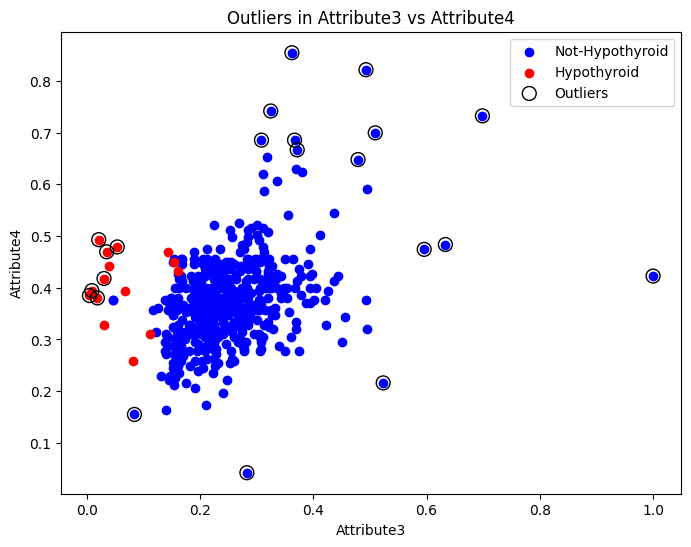

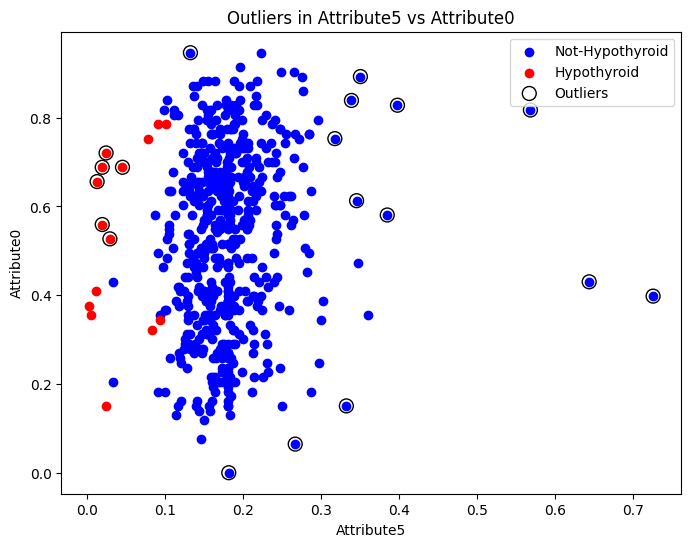

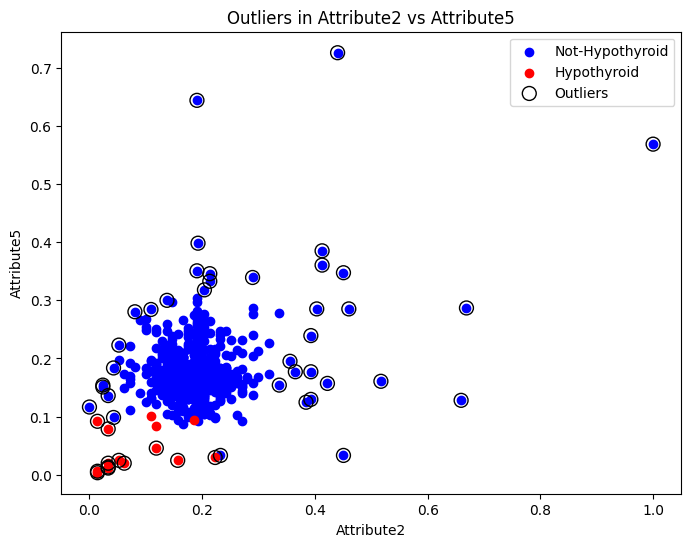

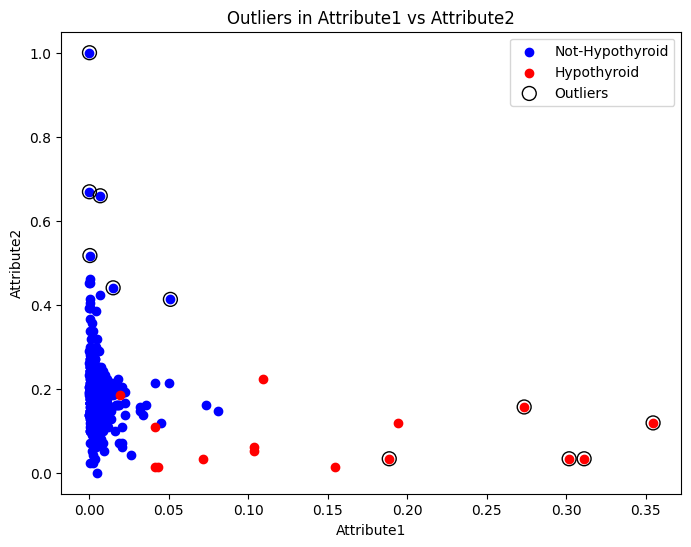

In [ ]:
for i, (feature_x, feature_y) in enumerate(all_feature_pairs):
    best_threshold = optimal_thresholds[i]

    # Fit Gaussian Mixture
    gm = GaussianMixture(n_components=2, random_state=0)
    gm.fit(X_val[[feature_x, feature_y]])

    # Compute scores and find outliers
    val_scores = gm.score_samples(X_val[[feature_x, feature_y]])
    outliers = (val_scores < best_threshold)

    # Scatter plot
    plt.figure(figsize=(8,6))
    plt.scatter(X_val[feature_x][y_val == 0], X_val[feature_y][y_val == 0], color='blue', label='Not-Hypothyroid')
    plt.scatter(X_val[feature_x][y_val == 1], X_val[feature_y][y_val == 1], color='red', label='Hypothyroid')

    # Highlight the outliers
    plt.scatter(X_val[feature_x][outliers], X_val[feature_y][outliers], facecolors='none', edgecolors='black', s=100, label='Outliers')

    plt.xlabel(feature_x)
    plt.ylabel(feature_y)
    plt.legend()
    plt.title(f'Outliers in {feature_x} vs {feature_y}')
    plt.show()

## 4. Class-Conditional Gaussian Models

Instead of a single anomaly score, fit separate Gaussians for each class — G1 (healthy) and G2 (hypothyroid). Classify a point as hypothyroid when `S1 < c × S2`, where S1 and S2 are the respective log-likelihoods and c is a tuned parameter.

### 4.1 Fitting G1 (Healthy) and G2 (Hypothyroid)

In [ ]:
# Select the feature (e.g., 'Attribute1')
feature = 'Attribute1'

# Fit a Gaussian on the feature for not-hypothyroid patients (class 0)
gm_not_hypothyroid = GaussianMixture(n_components=1, random_state=0)
gm_not_hypothyroid.fit(X_train[feature][y_train == 0].values.reshape(-1, 1))

print(f"Fitted Gaussian for not-hypothyroid patients on {feature}")

Fitted Gaussian for not-hypothyroid patients on Attribute1


In [ ]:
# Fit a Gaussian on the feature for hypothyroid patients (class 1)
gm_hypothyroid = GaussianMixture(n_components=1, random_state=0)
gm_hypothyroid.fit(X_train[feature][y_train == 1].values.reshape(-1, 1))

print(f"Fitted Gaussian for hypothyroid patients on {feature}")

Fitted Gaussian for hypothyroid patients on Attribute1


### 4.2 Log-Likelihood Scores (S1, S2)

In [ ]:
# Compute score samples for the validation set using both models
S1 = gm_not_hypothyroid.score_samples(X_val[feature].values.reshape(-1, 1))  # Scores for not-hypothyroid (G1)
S2 = gm_hypothyroid.score_samples(X_val[feature].values.reshape(-1, 1))  # Scores for hypothyroid (G2)

print(f"Computed score samples S1 (not-hypothyroid) and S2 (hypothyroid) for {feature}")

Computed score samples S1 (not-hypothyroid) and S2 (hypothyroid) for Attribute1


### 4.3 Optimising Decision Parameter c

In [ ]:
# Initialize variables to store the best F1 score and optimal c
best_f1 = 0
best_c = None

# Test values of c between 0 and 10 with a step of 0.1
c_values = np.arange(0, 10.1, 0.1)

for c in c_values:
    # Predict hypothyroid (class 1) if S1 < c * S2
    predictions = (S1 < c * S2).astype(int)

    # Compute F1 score
    f1 = f1_score(y_val, predictions)

    # Track the best F1 score and corresponding c
    if f1 > best_f1:
        best_f1 = f1
        best_c = c

print(f"Best F1 Score: {best_f1}, Best c: {best_c} for {feature}")

Best F1 Score: 0.8, Best c: 0.0 for Attribute1


### 4.4 Results Across All Features

In [ ]:
features = ['Attribute0', 'Attribute1', 'Attribute2', 'Attribute3', 'Attribute4', 'Attribute5']
best_f1_overall = 0
best_c_overall = None
best_feature = None

for feature in features:
    # Fit Gaussian for not-hypothyroid (G1)
    gm_not_hypothyroid = GaussianMixture(n_components=1, random_state=0)
    gm_not_hypothyroid.fit(X_train[feature][y_train == 0].values.reshape(-1, 1))

    # Fit Gaussian for hypothyroid (G2)
    gm_hypothyroid = GaussianMixture(n_components=1, random_state=0)
    gm_hypothyroid.fit(X_train[feature][y_train == 1].values.reshape(-1, 1))

    # Compute score samples
    S1 = gm_not_hypothyroid.score_samples(X_val[feature].values.reshape(-1, 1))
    S2 = gm_hypothyroid.score_samples(X_val[feature].values.reshape(-1, 1))

    # Find the optimal c and F1 score for this feature
    best_f1 = 0
    best_c = None
    for c in c_values:
        predictions = (S1 < c * S2).astype(int)
        f1 = f1_score(y_val, predictions)
        if f1 > best_f1:
            best_f1 = f1
            best_c = c

    print(f"Feature: {feature}, Best F1 Score: {best_f1}, Best c: {best_c}")

    # Track the best overall feature
    if best_f1 > best_f1_overall:
        best_f1_overall = best_f1
        best_c_overall = best_c
        best_feature = feature

print(f"Best overall feature: {best_feature}, Best F1 Score: {best_f1_overall}, Best c: {best_c_overall}")

Feature: Attribute0, Best F1 Score: 0.05952380952380952, Best c: 0.7000000000000001
Feature: Attribute1, Best F1 Score: 0.8, Best c: 0.0
Feature: Attribute2, Best F1 Score: 0.3829787234042553, Best c: 0.4
Feature: Attribute3, Best F1 Score: 0.7058823529411765, Best c: 0.30000000000000004
Feature: Attribute4, Best F1 Score: 0.1038961038961039, Best c: 0.9
Feature: Attribute5, Best F1 Score: 0.8, Best c: 0.30000000000000004
Best overall feature: Attribute1, Best F1 Score: 0.8, Best c: 0.0


## 5. Full Model Search: Multivariate Mixture of Gaussians

Open up the search space: any combination of features and any number of Gaussian components per class. Test 10+ configurations and track both training and validation AUC / F1 to identify the best model.

In [ ]:
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.metrics import roc_auc_score, f1_score
import pandas as pd

# Define the different combinations of features and number of components for the models
models = [
    {'features': ['Attribute0', 'Attribute1'], 'n_components_not_hypothyroid': 1, 'n_components_hypothyroid': 2},
    {'features': ['Attribute2', 'Attribute3'], 'n_components_not_hypothyroid': 1, 'n_components_hypothyroid': 3},
    {'features': ['Attribute0', 'Attribute2'], 'n_components_not_hypothyroid': 1, 'n_components_hypothyroid': 4},
    {'features': ['Attribute1', 'Attribute3'], 'n_components_not_hypothyroid': 2, 'n_components_hypothyroid': 2},
    {'features': ['Attribute0', 'Attribute4'], 'n_components_not_hypothyroid': 2, 'n_components_hypothyroid': 3},
    {'features': ['Attribute3', 'Attribute4'], 'n_components_not_hypothyroid': 1, 'n_components_hypothyroid': 1},
    {'features': ['Attribute2', 'Attribute5'], 'n_components_not_hypothyroid': 3, 'n_components_hypothyroid': 4},
    {'features': ['Attribute4', 'Attribute5'], 'n_components_not_hypothyroid': 1, 'n_components_hypothyroid': 2},
    {'features': ['Attribute1', 'Attribute4', 'Attribute5'], 'n_components_not_hypothyroid': 1, 'n_components_hypothyroid': 3},
    {'features': ['Attribute0', 'Attribute2', 'Attribute3'], 'n_components_not_hypothyroid': 2, 'n_components_hypothyroid': 2}
]

# Track the results for each model
results = []

for model in models:
    features = model['features']

    # Fit Gaussian for not-hypothyroid patients
    gm_not_hypothyroid = GaussianMixture(n_components=model['n_components_not_hypothyroid'], random_state=0)
    gm_not_hypothyroid.fit(X_train[features][y_train == 0])

    # Fit Gaussian for hypothyroid patients
    gm_hypothyroid = GaussianMixture(n_components=model['n_components_hypothyroid'], random_state=0)
    gm_hypothyroid.fit(X_train[features][y_train == 1])

    # Compute score samples for training set
    S1_train = gm_not_hypothyroid.score_samples(X_train[features])
    S2_train = gm_hypothyroid.score_samples(X_train[features])

    # Compute score samples for validation set
    S1_val = gm_not_hypothyroid.score_samples(X_val[features])
    S2_val = gm_hypothyroid.score_samples(X_val[features])

    # Initialize variables to store the best F1 score and optimal c for this model
    best_f1_train = 0
    best_f1_val = 0
    best_c_train = None
    best_c_val = None

    # Test values of c between 0 and 10 with a step of 0.1
    c_values = np.arange(0, 10.1, 0.1)

    for c in c_values:
        # Training set predictions
        train_predictions = (S1_train < c * S2_train).astype(int)
        f1_train = f1_score(y_train, train_predictions)

        # Validation set predictions
        val_predictions = (S1_val < c * S2_val).astype(int)
        f1_val = f1_score(y_val, val_predictions)

        # Track the best F1 score and corresponding c for training
        if f1_train > best_f1_train:
            best_f1_train = f1_train
            best_c_train = c

        # Track the best F1 score and corresponding c for validation
        if f1_val > best_f1_val:
            best_f1_val = f1_val
            best_c_val = c

    # Compute AUC for training and validation sets
    train_auc = roc_auc_score(y_train, S1_train)
    val_auc = roc_auc_score(y_val, S1_val)

    # Append results for this model
    results.append({
        'features': features,
        'n_components_not_hypothyroid': model['n_components_not_hypothyroid'],
        'n_components_hypothyroid': model['n_components_hypothyroid'],
        'train_auc': train_auc,
        'val_auc': val_auc,
        'best_f1_train': best_f1_train,
        'best_f1_val': best_f1_val,
        'best_c_train': best_c_train,
        'best_c_val': best_c_val
    })

# Convert results to a DataFrame for better presentation
results_df = pd.DataFrame(results)

# Display the results
print(results_df)  # Directly print the dataframe using pandas


                               features  n_components_not_hypothyroid  \
0              [Attribute0, Attribute1]                             1   
1              [Attribute2, Attribute3]                             1   
2              [Attribute0, Attribute2]                             1   
3              [Attribute1, Attribute3]                             2   
4              [Attribute0, Attribute4]                             2   
5              [Attribute3, Attribute4]                             1   
6              [Attribute2, Attribute5]                             3   
7              [Attribute4, Attribute5]                             1   
8  [Attribute1, Attribute4, Attribute5]                             1   
9  [Attribute0, Attribute2, Attribute3]                             2   

   n_components_hypothyroid  train_auc   val_auc  best_f1_train  best_f1_val  \
0                         2   0.030661  0.012341       0.693333     0.800000   
1                         3   0.0910

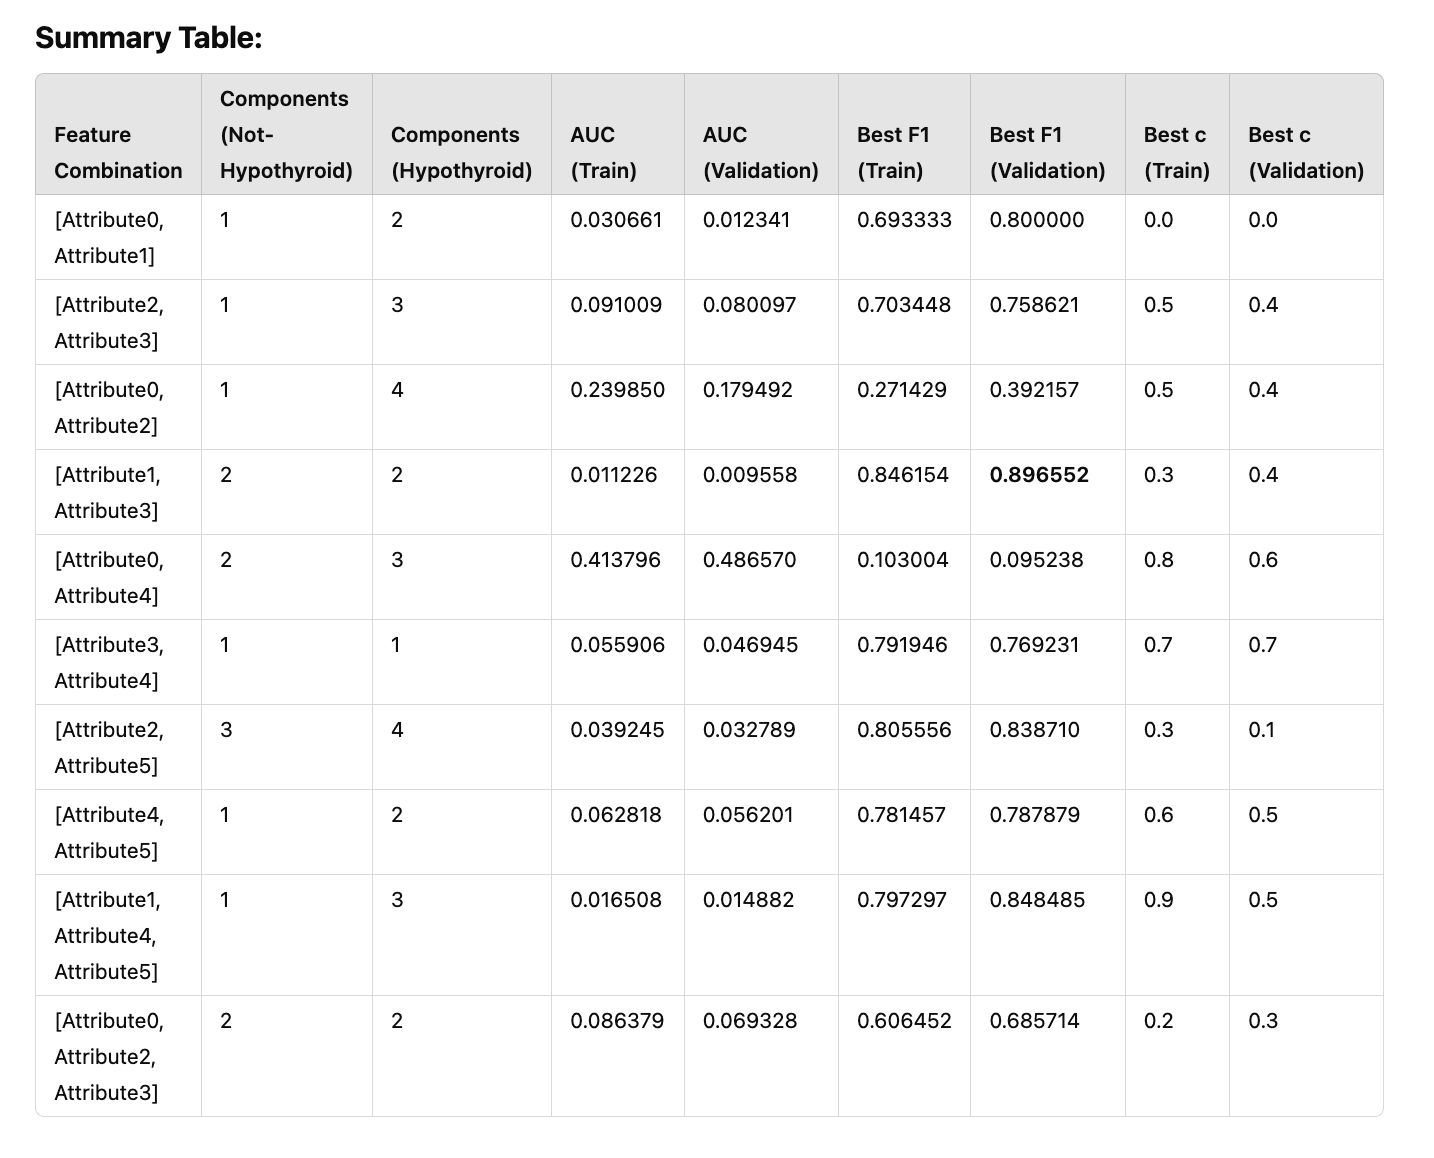

## 6. Test Set Evaluation

Apply the best model from Section 5 to the held-out test set. The best configuration was **Attribute1 + Attribute3, 2 components per class**.

### 6.1 Final Model Training

In [ ]:
# Assuming df is your full dataset
X = df[['Attribute0', 'Attribute1', 'Attribute2', 'Attribute3', 'Attribute4', 'Attribute5']]
y = df['hypothyroid']

# Split into training, validation, and test sets (70% train, 15% validation, 15% test)
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.15, random_state=0)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.1765, random_state=0)  # 0.1765*85% ≈ 15%

In [ ]:
# Fit the best GaussianMixture model on the full training set (combining X_train and X_val)
best_features = ['Attribute1', 'Attribute3']
n_components_not_hypothyroid = 2
n_components_hypothyroid = 2

# Fit Gaussian for not-hypothyroid patients
gm_not_hypothyroid = GaussianMixture(n_components=n_components_not_hypothyroid, random_state=0)
gm_not_hypothyroid.fit(X_train_val[best_features][y_train_val == 0])

# Fit Gaussian for hypothyroid patients
gm_hypothyroid = GaussianMixture(n_components=n_components_hypothyroid, random_state=0)
gm_hypothyroid.fit(X_train_val[best_features][y_train_val == 1])

# Compute score samples for the test set
S1_test = gm_not_hypothyroid.score_samples(X_test[best_features])
S2_test = gm_hypothyroid.score_samples(X_test[best_features])

# Optimal c found earlier was 0.4, apply it on the test set
c = 0.4
test_predictions = (S1_test < c * S2_test).astype(int)


### 6.2 Test Set Metrics

In [ ]:
# Import necessary libraries
from sklearn.metrics import f1_score, precision_score, recall_score

# Calculate F1 Score, Precision, and Recall on the test set
f1_test = f1_score(y_test, test_predictions)
precision_test = precision_score(y_test, test_predictions)
recall_test = recall_score(y_test, test_predictions)

print(f"F1 Score on Test Set: {f1_test}")
print(f"Precision on Test Set: {precision_test}")
print(f"Recall on Test Set: {recall_test}")

F1 Score on Test Set: 0.9375
Precision on Test Set: 0.8823529411764706
Recall on Test Set: 1.0


## 7. Alternative Distributions

Gaussian distributions are a natural starting point, but many real-world datasets violate normality assumptions.

**1. Log-Normal Distribution:**
The Log-Normal distribution is useful when the data is positively skewed and grows multiplicatively. It is widely used in finance to model stock prices, as asset returns are often multiplicative, and in economics for modeling income distributions. In a Log-Normal distribution, the logarithm of the variable is normally distributed, meaning that if your data spans several orders of magnitude and cannot be negative (e.g., income, prices, or biological measurements), the Log-Normal may provide a better fit than the Gaussian.

When it works better: In situations where data cannot take negative values and exhibits positive skew (e.g., income, waiting times).
Example: Modeling stock prices, where small changes multiply over time.

**Reference:**
Limpert, E., Stahel, W. A., & Abbt, M. (2001). "Log-normal distributions across the sciences: Keys and clues." BioScience, 51(5), 341-352.




**2. Weibull Distribution:**
The Weibull distribution is widely used in reliability engineering and failure analysis. It can model lifetimes of objects where the hazard rate (failure risk) changes over time, unlike the Gaussian which assumes symmetry. For example, machine parts may have a higher likelihood of failing as they age. The Weibull distribution offers flexibility in modeling data that has an increasing or decreasing failure rate, making it more suitable than Gaussian in many engineering and survival contexts.

When it works better: When modeling lifetimes or failure rates, particularly where the risk of failure changes over time (e.g., increasing wear and tear).
Example: Predicting the time until failure for mechanical parts.

**Reference:**
Abernethy, R. B. (2006). "The New Weibull Handbook." 5th edition, ISBN 0-9653062-1-6.

## 8. Conclusions & Key Findings

- **Best model:** Multivariate GMM on Attribute1 + Attribute3 with 2 components per class, selected via validation F1.
- **Class-conditional modelling outperformed single-distribution anomaly detection** — fitting separate Gaussians for each class and tuning the likelihood ratio threshold c gave better F1 than unsupervised anomaly scoring alone.
- **Extreme imbalance (2.5% positive rate) demands careful metric selection:** accuracy is meaningless here; F1 and AUC are the only reliable signals.
- **Feature distributions matter:** Attribute3 and Attribute5 showed near-Gaussian behaviour for the majority class, justifying the GMM approach. Skewed features (Attribute2) would benefit from a log-normal or multi-component model.

**Next steps:**
- Test log-normal and Weibull distributions on skewed features
- Explore SMOTE or cost-sensitive learning as an alternative to anomaly framing
- Evaluate on a stratified k-fold rather than a single validation split